In [11]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Main folder for all YOLO outputs
OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/yolo_nl_dl"
)

# Create the folder if it doesn't exist
OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:", OUTPUT_ROOT)
print("Folder exists:", OUTPUT_ROOT.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/yolo_nl_dl
Folder exists: True


In [2]:
!pip install -q -U ultralytics
!pip install -q kagglehub scikit-learn seaborn imagehash

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.7 MB/s eta 0:00:00


In [12]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available!")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [13]:
import os
import shutil
import random
import hashlib
import json
import gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import imagehash

from ultralytics import YOLO

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "mgmitesh/skin-disease-detection-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 2.65G/2.65G [00:34<00:00, 81.2MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1


In [15]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
}

image_files = []

# Convert dataset_path to a Path object to use rglob
for path in Path(dataset_path).rglob("*"):

    if (
        path.is_file()
        and path.suffix.lower()
        in IMAGE_EXTENSIONS
    ):
        image_files.append(path)

print(
    "Total images found:",
    len(image_files)
)

print("\nExample images:")

for p in image_files[:20]:
    print(p)

Total images found: 48233

Example images:
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1/train/Seborrheic Keratosis/ISIC_0011057.jpg
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1/train/Seborrheic Keratosis/ISIC_0011118_0_7274.jpeg
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1/train/Seborrheic Keratosis/ISIC_0011032_0_9346.jpeg
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1/train/Seborrheic Keratosis/ISIC_0010942_0_9798.jpeg
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1/train/Seborrheic Keratosis/ISIC_0011151_0_9126.jpeg
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1/train/Seborrheic Keratosis/ISIC_0011163_0_8616.jpeg
/root/.cache/kagglehub/datasets/mgmitesh/skin-disease-detection-dataset/versions/1/train/Seborrheic Keratosis/ISIC_0010923_0_2726.jpeg
/root/.cache/kaggleh

In [16]:
records = []

for path in image_files:

    records.append({
        "path": str(path),
        "filename": path.name,
        "parent": path.parent.name,
        "extension": path.suffix.lower()
    })

df = pd.DataFrame(records)

print(
    "Dataset shape:",
    df.shape
)

display(df.head())

Dataset shape: (48233, 4)


,path,filename,parent,extension
0,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,ISIC_0011057.jpg,Seborrheic Keratosis,.jpg
1,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,ISIC_0011118_0_7274.jpeg,Seborrheic Keratosis,.jpeg
2,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,ISIC_0011032_0_9346.jpeg,Seborrheic Keratosis,.jpeg
3,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,ISIC_0010942_0_9798.jpeg,Seborrheic Keratosis,.jpeg
4,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,ISIC_0011151_0_9126.jpeg,Seborrheic Keratosis,.jpeg


In [17]:
print("Parent directories:\n")

parent_counts = df["parent"].value_counts()

display(
    parent_counts.to_frame(
        "number_of_images"
    )
)

Parent directories:



,number_of_images
parent,
Nevus,3978
Acne,3604
Normal Skin,3337
Chickenpox,3301
Actinic Keratosis,3267
Ringworm,3229
Melanoma,3213
Dermato Fibroma,3138
Basal Cell Carcinoma,3125


In [18]:
for parent in sorted(df["parent"].unique()):

    count = (
        df["parent"] == parent
    ).sum()

    print(
        f"{parent:40s} {count:5d}"
    )

Acne                                      3604
Actinic Keratosis                         3267
Basal Cell Carcinoma                      3125
Chickenpox                                3301
Dermato Fibroma                           3138
Dyshidrotic Eczema                        2925
Melanoma                                  3213
Nail Fungus                               3121
Nevus                                     3978
Normal Skin                               3337
Pigmented Benign Keratosis                3050
Ringworm                                  3229
Seborrheic Keratosis                      2921
Squamous Cell Carcinoma                   2909
Vascular Lesion                           3115


In [19]:
def detect_split(path):

    parts = Path(path).parts

    lower_parts = [
        p.lower()
        for p in parts
    ]

    if "train" in lower_parts:
        return "train"

    if "val" in lower_parts:
        return "val"

    if "valid" in lower_parts:
        return "val"

    if "test" in lower_parts:
        return "test"

    return "unknown"


df["split"] = df["path"].apply(
    detect_split
)

display(
    df["split"].value_counts()
)

,count
split,
train,46334
val,1899


In [20]:
def get_class_from_path(path):

    parts = list(Path(path).parts)

    lower = [
        p.lower()
        for p in parts
    ]

    for split_name in [
        "train",
        "val",
        "valid",
        "test"
    ]:

        if split_name in lower:

            idx = lower.index(
                split_name
            )

            if idx + 1 < len(parts):
                return parts[idx + 1]

    return Path(path).parent.name


df["class"] = df["path"].apply(
    get_class_from_path
)

print(
    "Number of classes:",
    df["class"].nunique()
)

print("\nClasses:")

for i, cls in enumerate(
    sorted(df["class"].unique())
):
    print(
        f"{i:2d}. {cls}"
    )

Number of classes: 15

Classes:
 0. Acne
 1. Actinic Keratosis
 2. Basal Cell Carcinoma
 3. Chickenpox
 4. Dermato Fibroma
 5. Dyshidrotic Eczema
 6. Melanoma
 7. Nail Fungus
 8. Nevus
 9. Normal Skin
10. Pigmented Benign Keratosis
11. Ringworm
12. Seborrheic Keratosis
13. Squamous Cell Carcinoma
14. Vascular Lesion


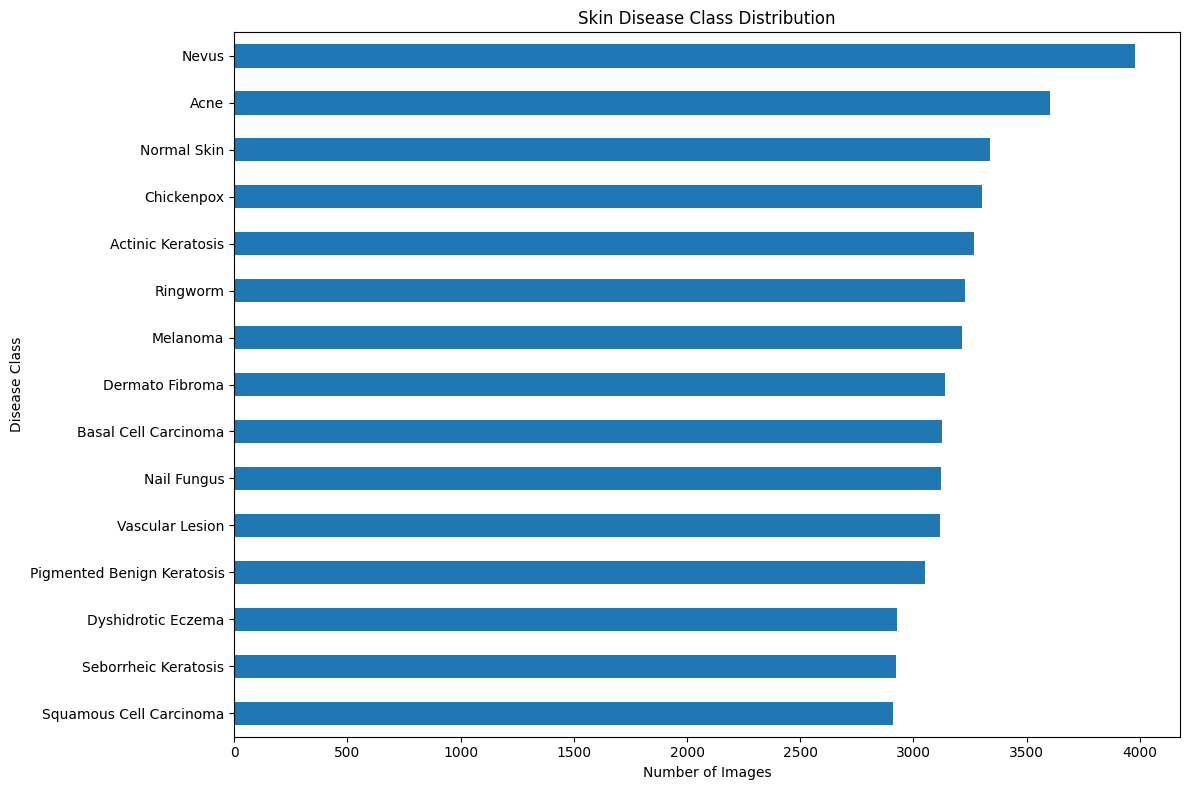

In [21]:
class_counts = (
    df["class"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

class_counts.plot(
    kind="barh"
)

plt.title(
    "Skin Disease Class Distribution"
)

plt.xlabel(
    "Number of Images"
)

plt.ylabel(
    "Disease Class"
)

plt.tight_layout()
plt.show()

In [22]:
largest = class_counts.max()
smallest = class_counts.min()

print(
    "Largest class:",
    largest
)

print(
    "Smallest class:",
    smallest
)

print(
    "Imbalance ratio:",
    round(
        largest / smallest,
        2
    )
)

Largest class: 3978
Smallest class: 2909
Imbalance ratio: 1.37


In [23]:
valid_images = []
corrupt_images = []

print("Checking image integrity...")

for path in image_files:

    try:
        with Image.open(path) as img:
            img.verify()

        valid_images.append(path)

    except Exception as e:
        corrupt_images.append(
            (path, str(e))
        )

print(
    "Valid images:",
    len(valid_images)
)

print(
    "Corrupt images:",
    len(corrupt_images)
)

if corrupt_images:

    print("\nCorrupt files:")

    for path, error in corrupt_images[:20]:
        print(path)

Checking image integrity...
Valid images: 48233
Corrupt images: 0


In [24]:
valid_path_strings = {
    str(p)
    for p in valid_images
}

clean_df = df[
    df["path"].isin(
        valid_path_strings
    )
].copy()

clean_df.reset_index(
    drop=True,
    inplace=True
)

print(
    "Images after cleaning:",
    len(clean_df)
)

Images after cleaning: 48233


In [25]:
valid_path_strings = {
    str(p)
    for p in valid_images
}

clean_df = df[
    df["path"].isin(
        valid_path_strings
    )
].copy()

clean_df.reset_index(
    drop=True,
    inplace=True
)

print(
    "Images after cleaning:",
    len(clean_df)
)

Images after cleaning: 48233


In [26]:
widths = []
heights = []

for path in clean_df["path"]:

    try:

        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)

    except:

        widths.append(None)
        heights.append(None)


clean_df["width"] = widths
clean_df["height"] = heights

clean_df["aspect_ratio"] = (
    clean_df["width"]
    /
    clean_df["height"]
)

display(
    clean_df[
        [
            "width",
            "height",
            "aspect_ratio"
        ]
    ].describe()
)

,width,height,aspect_ratio
count,48233.000000,48233.000000,48233.000000
mean,415.461510,353.988410,1.122103
std,312.243234,236.475911,0.206997
min,100.000000,100.000000,0.460417
25%,224.000000,224.000000,1.000000
50%,224.000000,224.000000,1.000000
75%,600.000000,450.000000,1.333333
max,6688.000000,4479.000000,3.870647


In [27]:
def md5_hash(path):

    hash_md5 = hashlib.md5()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(8192),
            b""
        ):

            hash_md5.update(
                chunk
            )

    return hash_md5.hexdigest()


print(
    "Calculating image hashes..."
)

clean_df["md5"] = [
    md5_hash(path)
    for path in clean_df["path"]
]

duplicate_groups = (
    clean_df["md5"]
    .value_counts()
)

duplicate_groups = (
    duplicate_groups[
        duplicate_groups > 1
    ]
)

print(
    "Duplicate groups:",
    len(duplicate_groups)
)

print(
    "Duplicate images involved:",
    duplicate_groups.sum()
)

Calculating image hashes...
Duplicate groups: 180
Duplicate images involved: 369


In [28]:
if len(duplicate_groups) > 0:

    duplicate_hashes = set(
        duplicate_groups.index
    )

    duplicates_df = clean_df[
        clean_df["md5"].isin(
            duplicate_hashes
        )
    ].sort_values("md5")

    display(
        duplicates_df[
            [
                "path",
                "class",
                "split",
                "md5"
            ]
        ].head(50)
    )

else:

    print(
        "No exact duplicates found."
    )

,path,class,split,md5
45770,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Dyshidrotic Eczema,train,059dede54deb243268fc11adefeadb67
45158,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Dyshidrotic Eczema,train,059dede54deb243268fc11adefeadb67
1591,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Seborrheic Keratosis,train,072afbd645cef562dd881a186c65e77c
33044,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Melanoma,train,072afbd645cef562dd881a186c65e77c
45590,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Dyshidrotic Eczema,train,079044605ff20f1f69d29625fb88f139
47995,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Dyshidrotic Eczema,val,079044605ff20f1f69d29625fb88f139
22925,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Acne,train,079635a91f252b701333251b8db159af
22369,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Acne,train,079635a91f252b701333251b8db159af
24667,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Acne,train,08250f50d02bc033d63eddded24956a7
22366,/root/.cache/kagglehub/datasets/mgmitesh/skin-...,Acne,train,08250f50d02bc033d63eddded24956a7


In [29]:
hash_split = (
    clean_df
    .groupby("md5")["split"]
    .nunique()
)

leak_hashes = hash_split[
    hash_split > 1
].index

print(
    "Exact duplicate groups appearing "
    "in multiple splits:",
    len(leak_hashes)
)

Exact duplicate groups appearing in multiple splits: 21


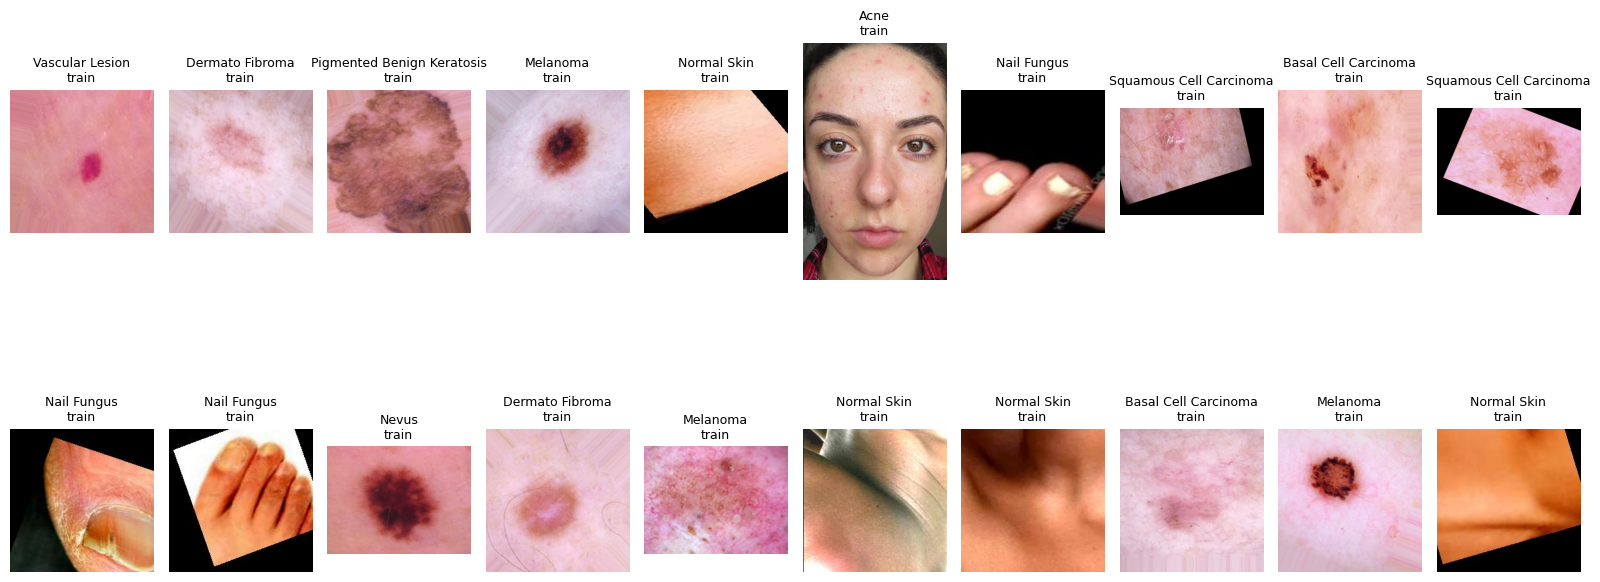

In [30]:
def show_random_images(
    dataframe,
    n=20
):

    sample = dataframe.sample(
        min(n, len(dataframe)),
        random_state=SEED
    )

    cols = 10
    rows = int(
        np.ceil(
            len(sample) / cols
        )
    )

    plt.figure(
        figsize=(16, 4 * rows)
    )

    for i, (_, row) in enumerate(
        sample.iterrows()
    ):

        img = Image.open(
            row["path"]
        ).convert("RGB")

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        ax.imshow(img)

        ax.set_title(
            f'{row["class"]}\n'
            f'{row["split"]}',
            fontsize=9
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_random_images(
    clean_df,
    20
)

In [31]:
WORK_DIR = Path(
    "/content/skin_yolo_dataset"
)

if WORK_DIR.exists():
    shutil.rmtree(
        WORK_DIR
    )

WORK_DIR.mkdir(
    parents=True
)

print(
    "Working directory:",
    WORK_DIR
)

Working directory: /content/skin_yolo_dataset


In [32]:
WORK_DIR = Path(
    "/content/skin_yolo_dataset"
)

if WORK_DIR.exists():
    shutil.rmtree(
        WORK_DIR
    )

WORK_DIR.mkdir(
    parents=True
)

print(
    "Working directory:",
    WORK_DIR
)

Working directory: /content/skin_yolo_dataset


In [33]:
classes = sorted(
    clean_df["class"].unique()
)

print(
    f"Number of classes: {len(classes)}"
)

for split in ["train", "val"]:

    for cls in classes:

        (
            WORK_DIR
            / split
            / cls
        ).mkdir(
            parents=True,
            exist_ok=True
        )

Number of classes: 15


In [34]:
def copy_images_to_yolo(
    dataframe,
    split_name
):

    split_df = dataframe[
        dataframe["split"] == split_name
    ]

    print(
        f"\nCopying {split_name} images..."
    )

    for _, row in split_df.iterrows():

        src = Path(
            row["path"]
        )

        cls = row["class"]

        destination_dir = (
            WORK_DIR
            / split_name
            / cls
        )

        destination = (
            destination_dir
            / src.name
        )

        # Avoid filename collision
        if destination.exists():

            destination = (
                destination_dir
                /
                f"{src.stem}_{hash(src)}"
                f"{src.suffix}"
            )

        shutil.copy2(
            src,
            destination
        )


copy_images_to_yolo(
    clean_df,
    "train"
)

copy_images_to_yolo(
    clean_df,
    "val"
)

print(
    "YOLO dataset created."
)


Copying train images...

Copying val images...
YOLO dataset created.


In [35]:
for split in [
    "train",
    "val"
]:

    print(
        f"\n===== {split.upper()} ====="
    )

    total = 0

    for cls in classes:

        count = len(
            list(
                (
                    WORK_DIR
                    / split
                    / cls
                ).glob("*")
            )
        )

        total += count

        print(
            f"{cls:35s}: {count}"
        )

    print(
        "TOTAL:",
        total
    )


===== TRAIN =====
Acne                               : 3283
Actinic Keratosis                  : 3227
Basal Cell Carcinoma               : 3082
Chickenpox                         : 3293
Dermato Fibroma                    : 3116
Dyshidrotic Eczema                 : 2600
Melanoma                           : 3158
Nail Fungus                        : 2967
Nevus                              : 3211
Normal Skin                        : 3315
Pigmented Benign Keratosis         : 2960
Ringworm                           : 3210
Seborrheic Keratosis               : 2918
Squamous Cell Carcinoma            : 2893
Vascular Lesion                    : 3101
TOTAL: 46334

===== VAL =====
Acne                               : 321
Actinic Keratosis                  : 40
Basal Cell Carcinoma               : 43
Chickenpox                         : 8
Dermato Fibroma                    : 22
Dyshidrotic Eczema                 : 325
Melanoma                           : 55
Nail Fungus                        : 154

In [36]:
MODEL_NAME = "yolo26s-cls.pt"

model = YOLO(
    MODEL_NAME
)

print(
    "Loaded:",
    MODEL_NAME
)

Loaded: yolo26s-cls.pt


In [37]:
baseline_results = model.train(
    data=str(WORK_DIR),

    epochs=40,
    imgsz=224,
    batch=32,

    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    patience=10,

    device=0,

    # Save training outputs directly to Google Drive
    project=str(OUTPUT_ROOT / "yolo_runs"),
    name="baseline_224",

    # Save training outputs and allow plots to be generated
    save=True,
    save_period=-1,
    plots=True,

    verbose=True
)

print("Training completed.")
print("Training results saved to:")
print(OUTPUT_ROOT / "yolo_runs" / "baseline_224")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/skin_yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_224, nbs=64, nms=None, opset=None, optimize=Fals

In [38]:
BASELINE_PATH = (
    OUTPUT_ROOT
    / "yolo_runs"
    / "baseline_224"
    / "weights"
    / "best.pt"
)

print("Best model:", BASELINE_PATH)
print("Model exists:", BASELINE_PATH.exists())

if BASELINE_PATH.exists():
    baseline_model = YOLO(str(BASELINE_PATH))
    print("Best model loaded successfully.")
else:
    print("Model file not found. Check the training output directory.")

Best model: /content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.pt
Model exists: True
Best model loaded successfully.


In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from ultralytics import YOLO

# ============================================================
# CHANGE ONLY THIS IF YOUR RUN HAS A DIFFERENT NAME
# ============================================================

RUN_DIR = (
    OUTPUT_ROOT
    / "yolo_runs"
    / "baseline_224"
)

BEST_MODEL = (
    RUN_DIR
    / "weights"
    / "best.pt"
)

RESULTS_CSV = RUN_DIR / "results.csv"

print("Run directory:", RUN_DIR)
print("Best model:", BEST_MODEL)
print("Results CSV:", RESULTS_CSV)

print("\nRun directory exists:", RUN_DIR.exists())
print("Best model exists:", BEST_MODEL.exists())
print("Results CSV exists:", RESULTS_CSV.exists())

print("\nFiles in run directory:")

if RUN_DIR.exists():
    for file in sorted(RUN_DIR.rglob("*")):
        if file.is_file():
            print(file)

BEST_MODEL = RUN_DIR / "weights" / "best.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Run directory:", RUN_DIR)
print("Best model:", BEST_MODEL)
print("Results CSV:", RESULTS_CSV)

print("\nFiles in run directory:")
for file in RUN_DIR.rglob("*"):
    print(file)

Run directory: /content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224
Best model: /content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.pt
Results CSV: /content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/results.csv

Run directory exists: True
Best model exists: True
Results CSV exists: True

Files in run directory:
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/args.yaml
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/confusion_matrix.png
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/confusion_matrix_normalized.png
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/results.csv
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/results.png
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/train_batch0.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/train_batch1.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/train_batch2.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/train_ba

In [40]:
print("Available output files:\n")

for file in sorted(RUN_DIR.rglob("*")):
    if file.is_file():
        print(file.name)

Available output files:

args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch43440.jpg
train_batch43441.jpg
train_batch43442.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
best.pt
last.pt


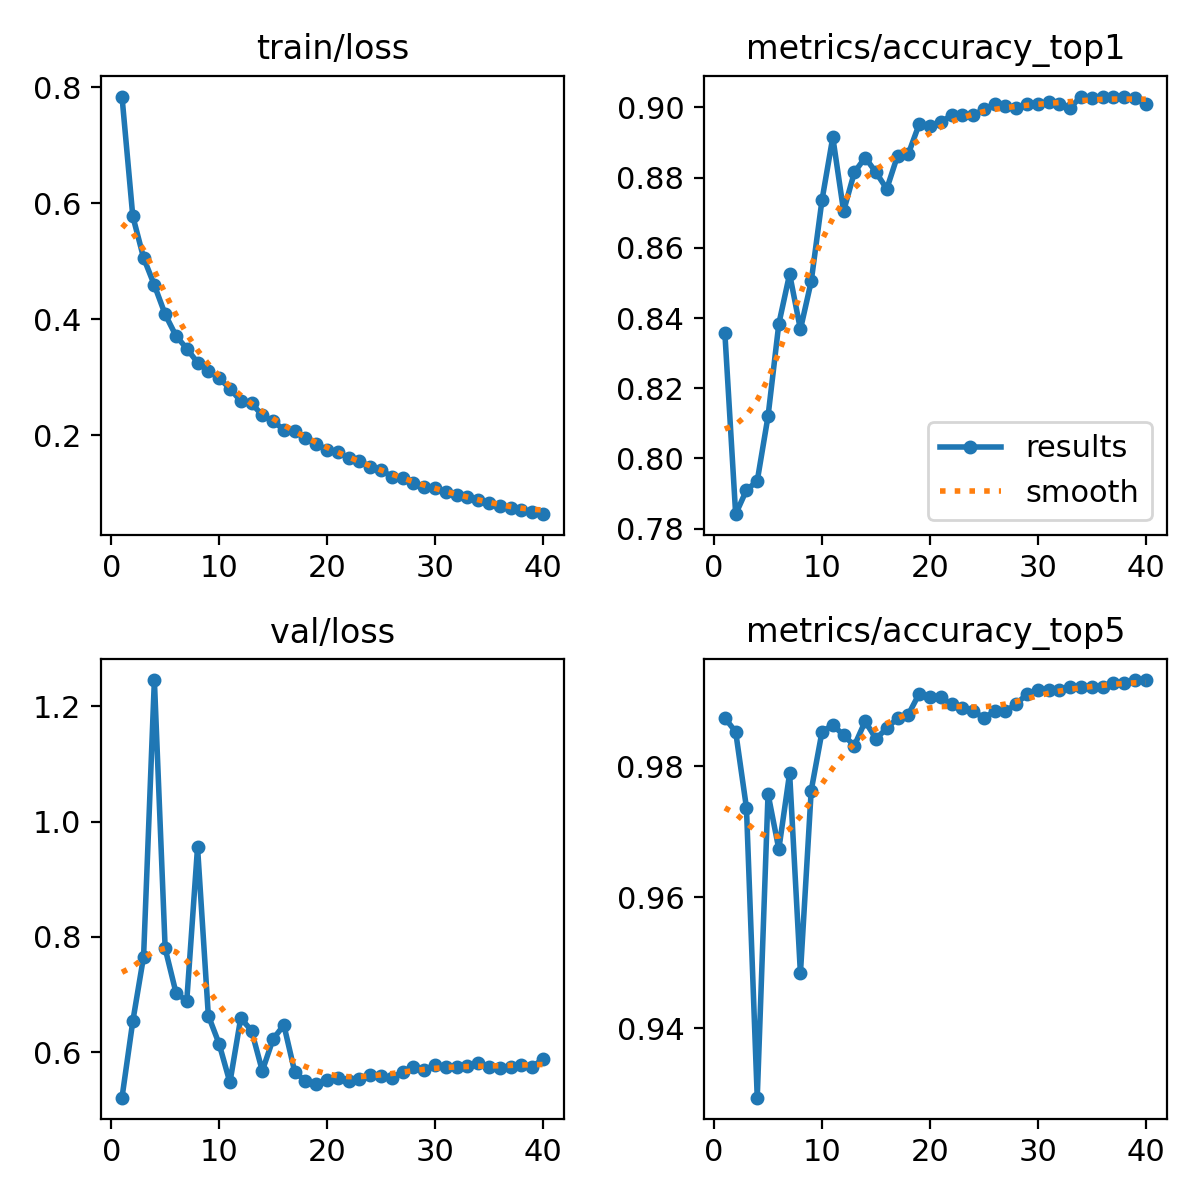

In [41]:
results_png = RUN_DIR / "results.png"

if results_png.exists():

    display(
        Image.open(results_png)
    )

else:

    print(
        "results.png was not found."
    )

In [42]:
history = pd.read_csv(
    RESULTS_CSV
)

print(
    "Number of epochs recorded:",
    len(history)
)

display(
    history.head()
)

Number of epochs recorded: 40


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,363.491,0.78421,0.83570,0.98736,0.52108,0.000333,0.000333,0.067023
1,2,728.647,0.57791,0.78410,0.98526,0.65342,0.000650,0.000650,0.034006
2,3,1093.830,0.50624,0.79094,0.97367,0.76554,0.000950,0.000950,0.000973
3,4,1452.000,0.45900,0.79358,0.92944,1.24534,0.000926,0.000926,0.000926
4,5,1803.380,0.40869,0.81201,0.97578,0.77982,0.000901,0.000901,0.000901


In [43]:
print(
    "Available columns:"
)

for column in history.columns:
    print(column)

Available columns:
epoch
time
train/loss
metrics/accuracy_top1
metrics/accuracy_top5
val/loss
lr/pg0
lr/pg1
lr/pg2


In [44]:
loss_columns = [
    column
    for column in history.columns
    if "loss" in column.lower()
]

print(
    "Loss columns:",
    loss_columns
)

Loss columns: ['train/loss', 'val/loss']


In [45]:
top1_columns = [
    column
    for column in history.columns
    if "top1" in column.lower()
]

print(
    "Top-1 columns:",
    top1_columns
)

Top-1 columns: ['metrics/accuracy_top1']


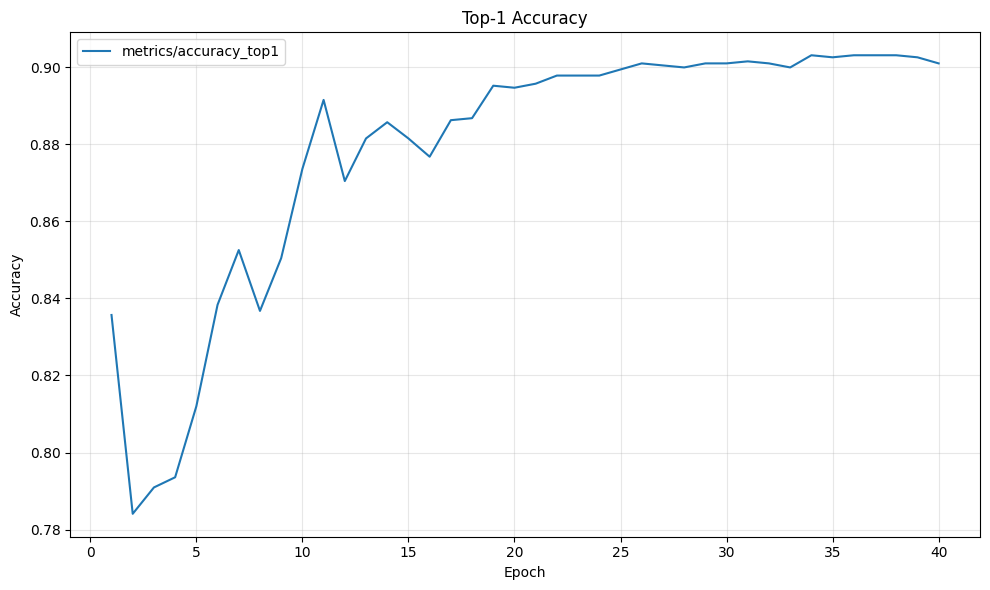

In [46]:
plt.figure(
    figsize=(10, 6)
)

for column in top1_columns:

    plt.plot(
        history["epoch"],
        history[column],
        label=column
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


 confusion_matrix.png


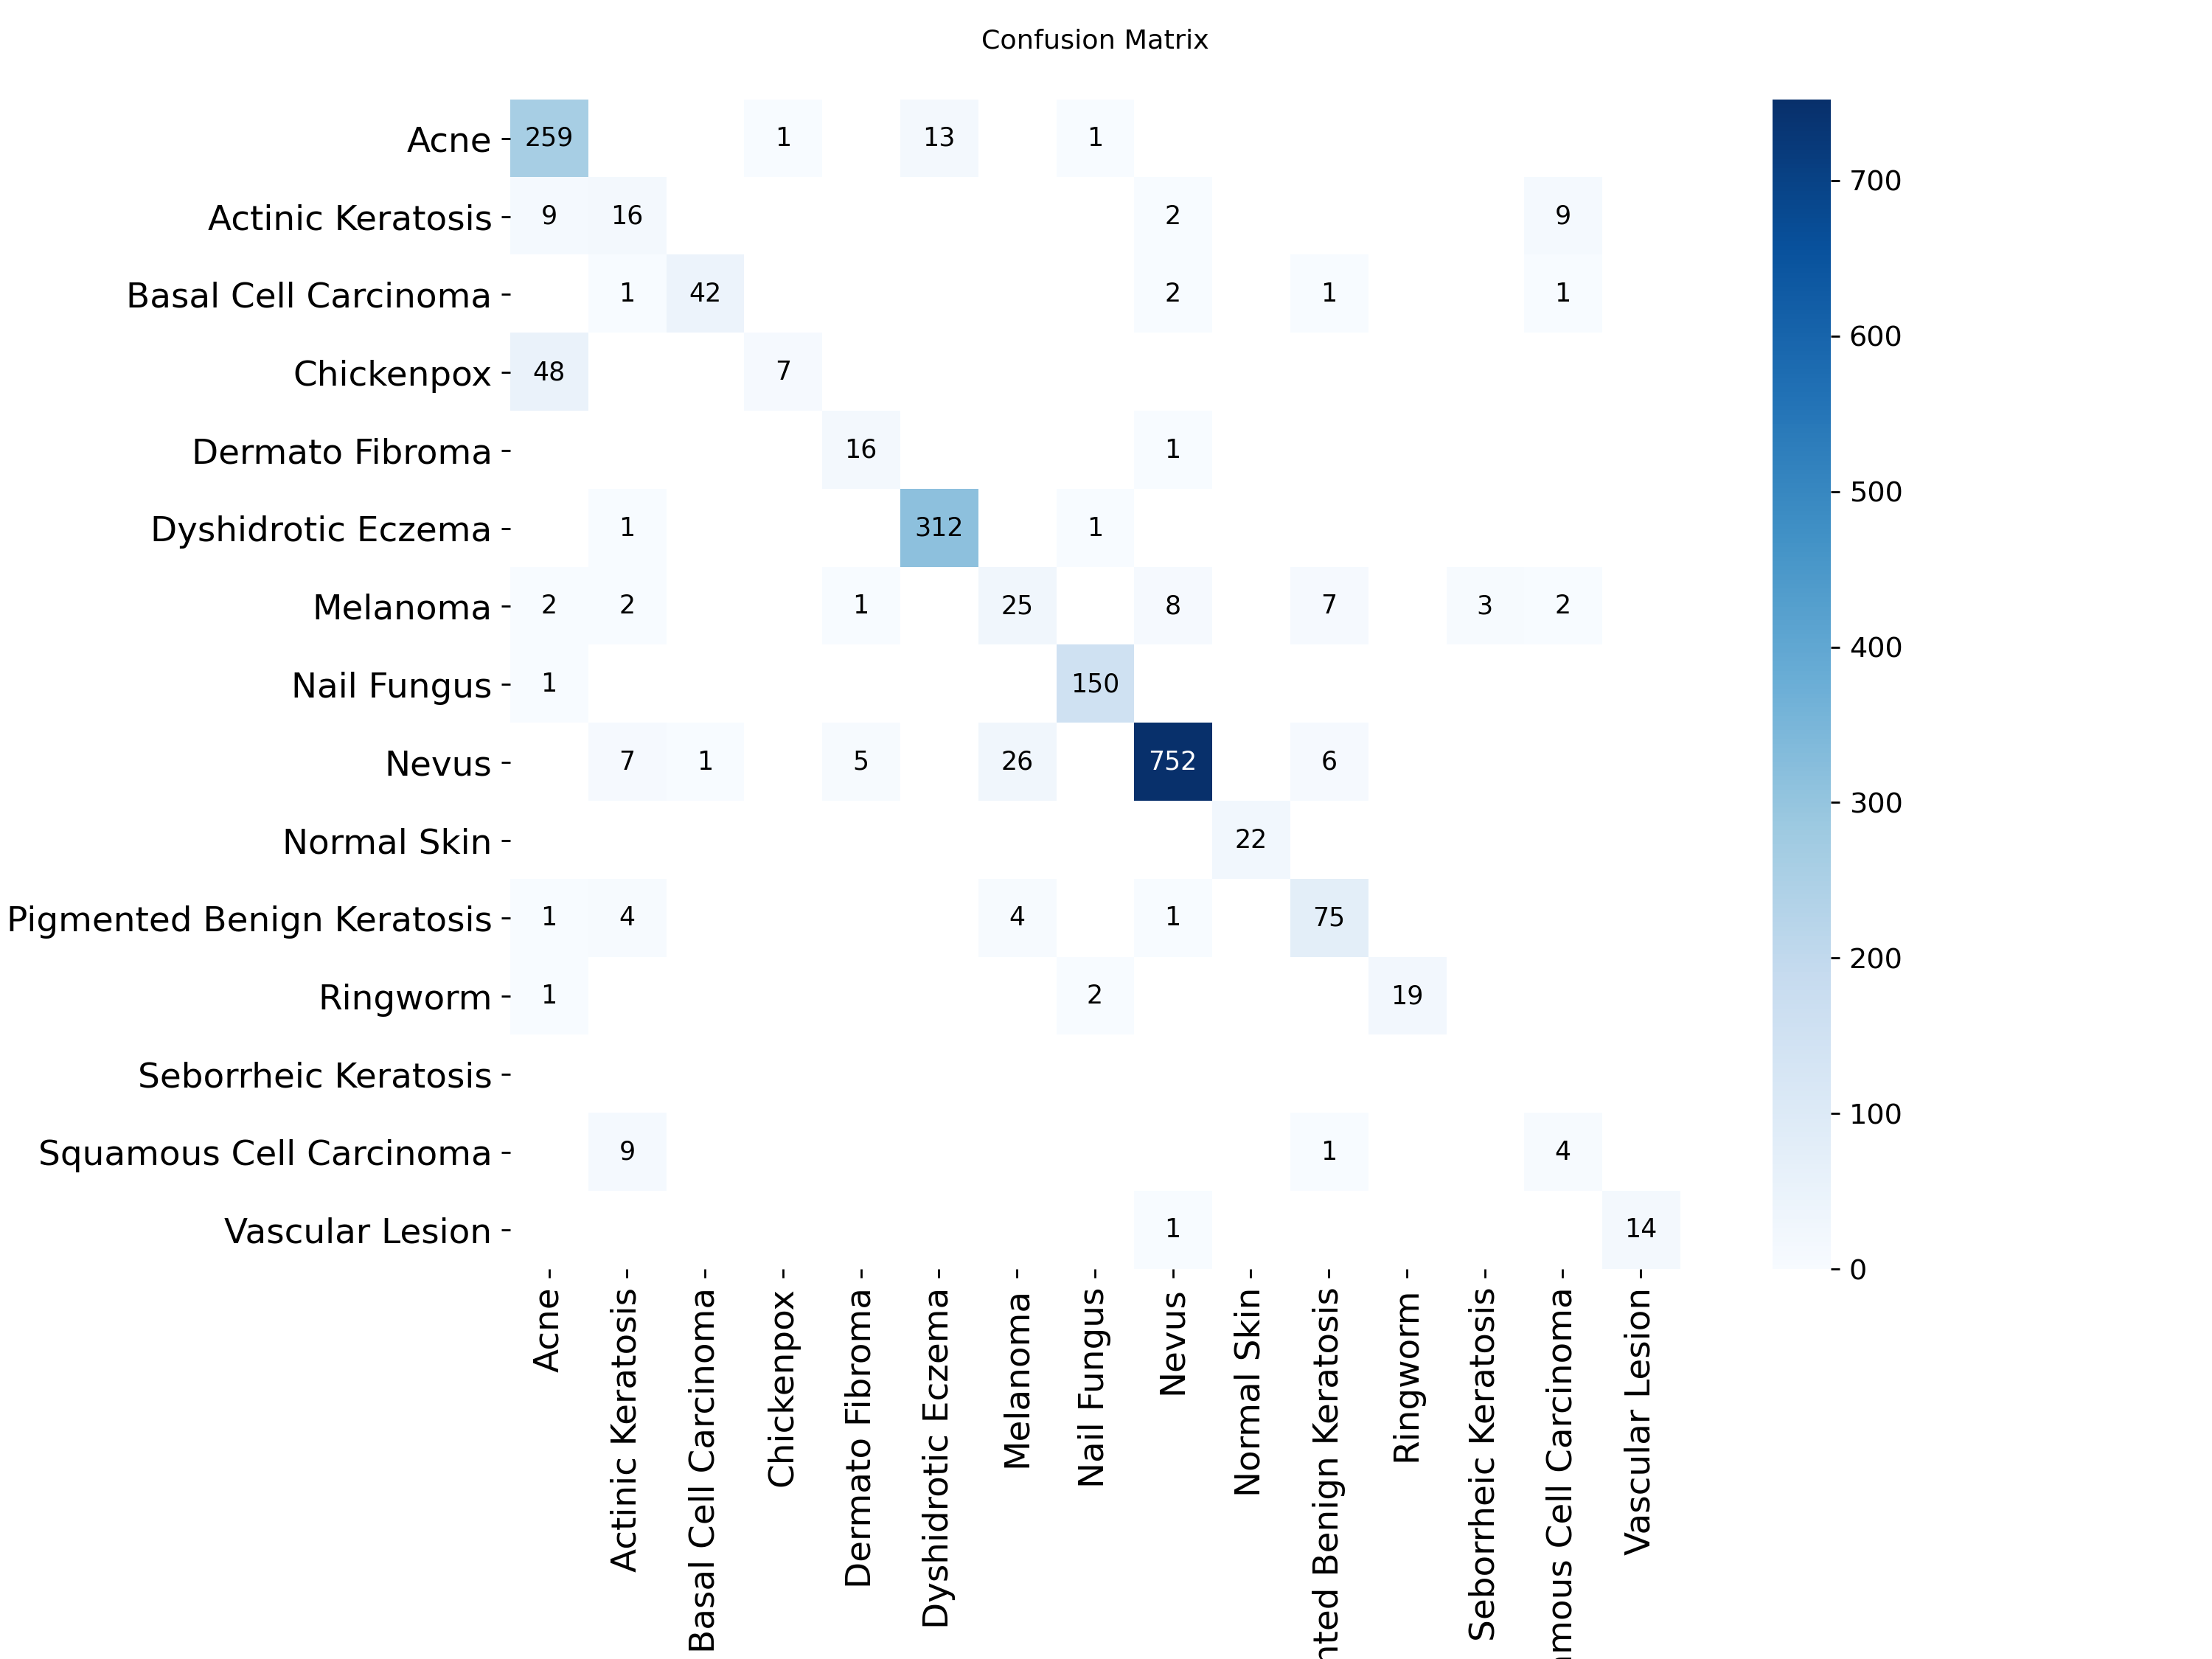


 confusion_matrix_normalized.png


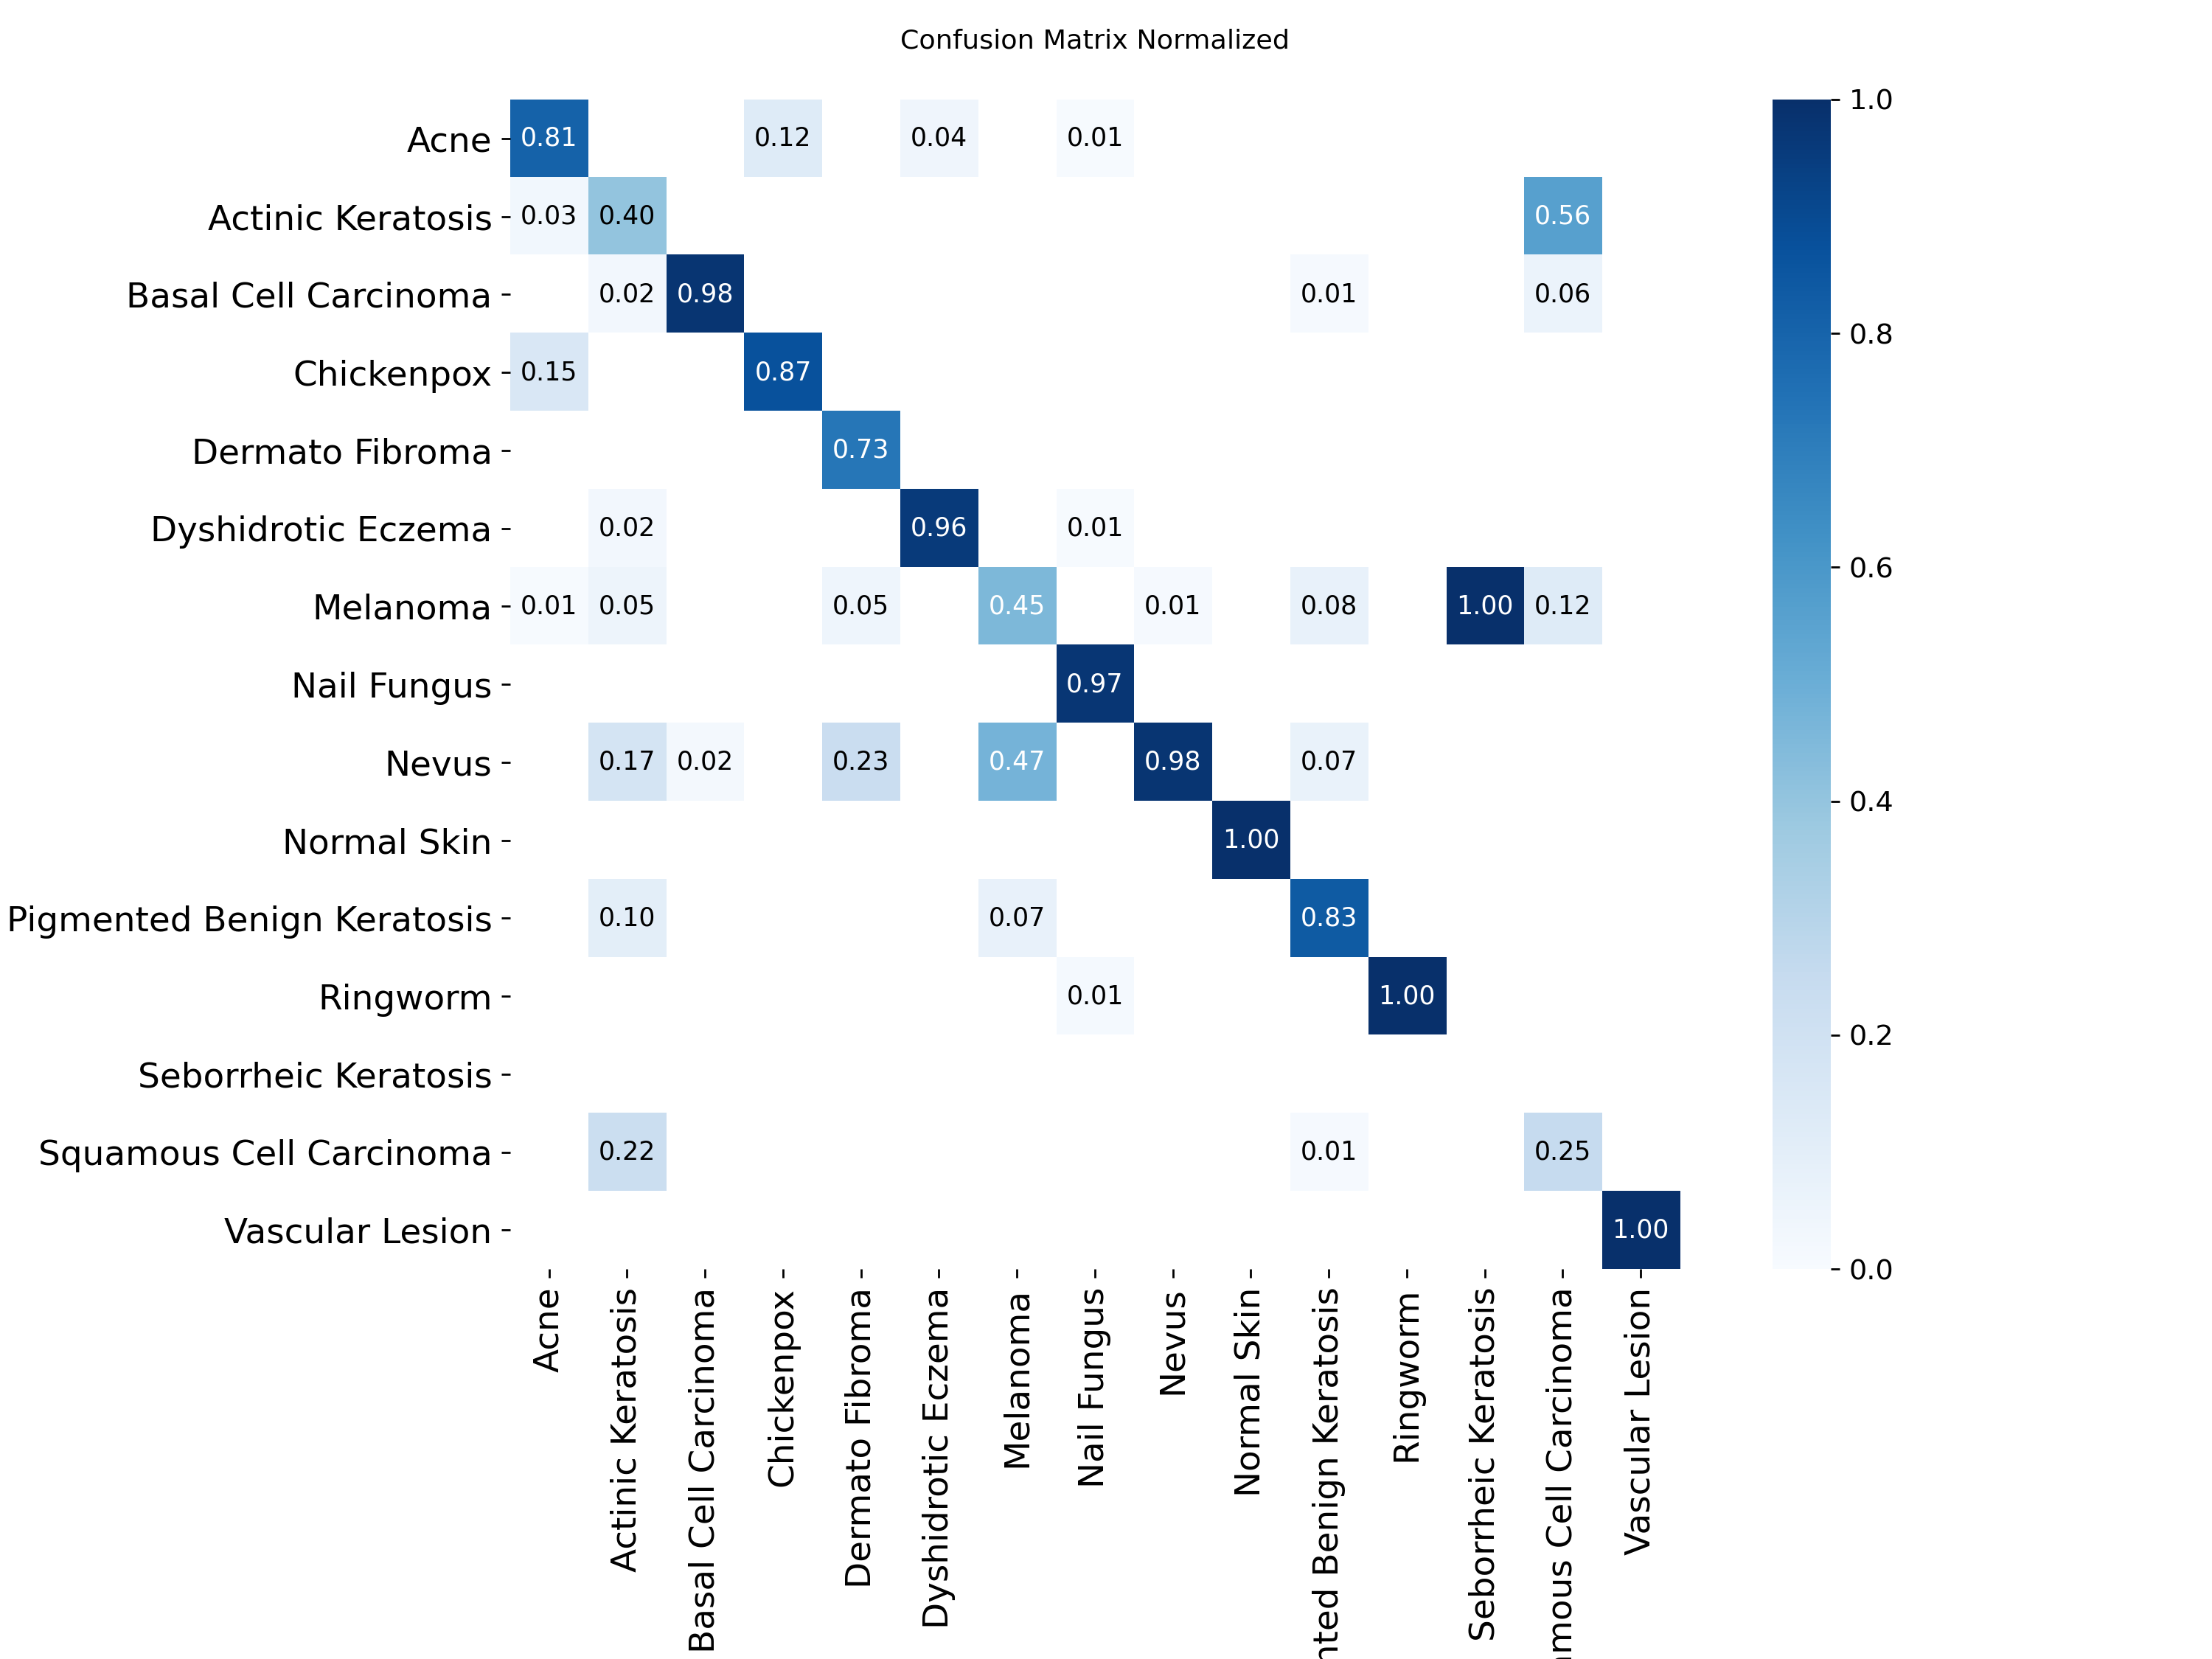

In [47]:
possible_cm_files = [
    RUN_DIR / "confusion_matrix.png",
    RUN_DIR / "confusion_matrix_normalized.png"
]

for cm_file in possible_cm_files:

    if cm_file.exists():

        print(
            "\n",
            cm_file.name
        )

        display(
            Image.open(cm_file)
        )

In [50]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import math

# Your training output directory
RUN_DIR = (
    OUTPUT_ROOT
    / "yolo_runs"
    / "baseline_224"
)

# Find validation batch images
val_images = sorted(
    list(RUN_DIR.glob("val_batch*.jpg"))
)

print(f"Found {len(val_images)} validation images")

for img in val_images:
    print(img)

Found 6 validation images
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/val_batch0_labels.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/val_batch0_pred.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/val_batch1_labels.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/val_batch1_pred.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/val_batch2_labels.jpg
/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/val_batch2_pred.jpg


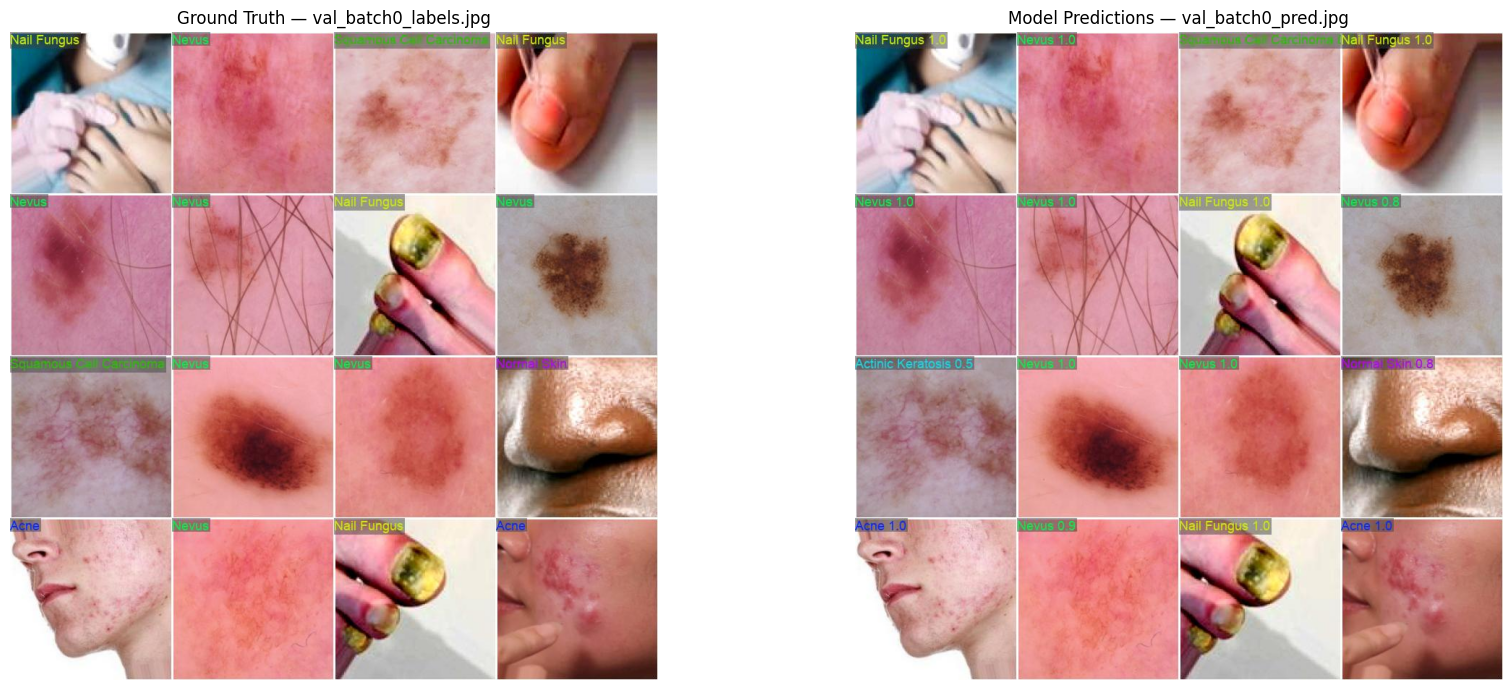

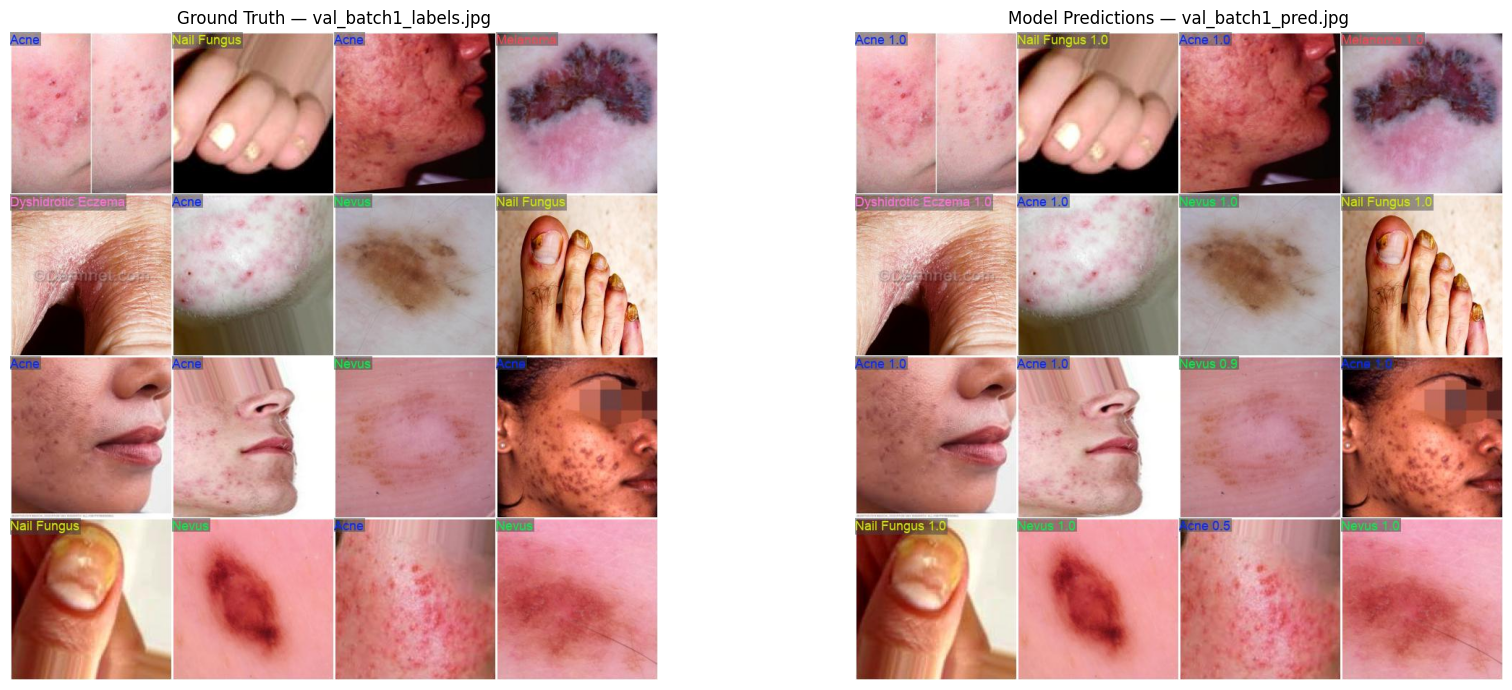

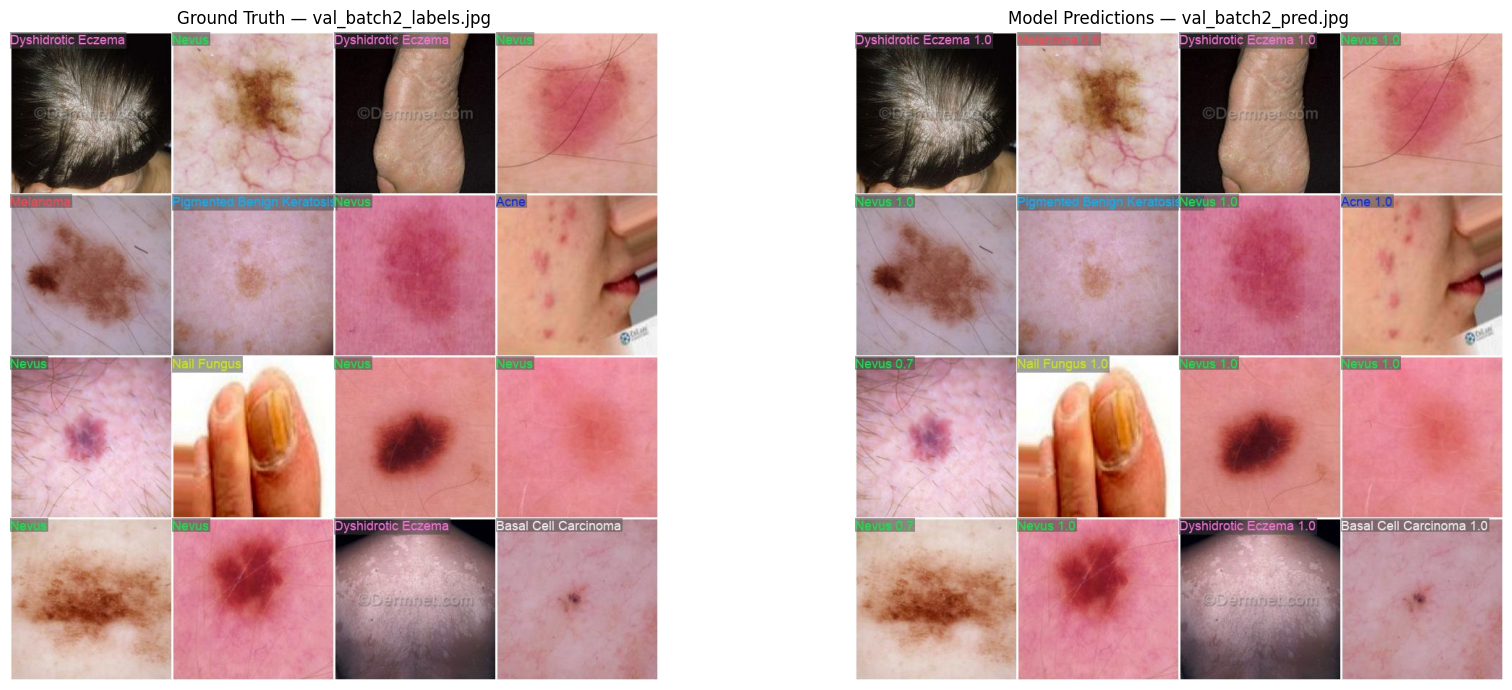

In [52]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

RUN_DIR = (
    OUTPUT_ROOT
    / "yolo_runs"
    / "baseline_224"
)

label_images = sorted(
    RUN_DIR.glob("val_batch*_labels.jpg")
)

pred_images = sorted(
    RUN_DIR.glob("val_batch*_pred.jpg")
)

num_batches = min(
    len(label_images),
    len(pred_images)
)

for i in range(num_batches):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 7)
    )

    # Ground truth
    axes[0].imshow(
        Image.open(label_images[i])
    )

    axes[0].set_title(
        "Ground Truth — " +
        label_images[i].name
    )

    axes[0].axis("off")

    # Predictions
    axes[1].imshow(
        Image.open(pred_images[i])
    )

    axes[1].set_title(
        "Model Predictions — " +
        pred_images[i].name
    )

    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [54]:
!pip install -U ultralytics

In [56]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.pt"
)

model.export(format="tflite")

WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26s-cls summary (fused): 47 layers, 5,453,343 parameters, 0 gradients, 1.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 15) (10.5 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 86 packages in 675ms
Prepared 16 packages in 2.00s
Uninstalled 4 packages in 42ms
Installed 16 packages in 44ms
 + ai-edge-litert==2.2

/usr/local/lib/python3.13/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:11) [ DONE] LiteRT-Torch Convert (+00:11)

(00:00) [START] Write Model to /content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.tflite

(00:00) [ DONE] Write Model to /content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.tflite 
(+00:00)

LiteRT: export success ✅ 20.4s, saved as '/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.tflite' (20.9 MB)

Export complete (20.8s)
Results saved to /content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.tflite
Predict:         yolo predict task=classify model=/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.tflite imgsz=224 
Validate:        yolo val task=classify model=/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.tflite imgsz=224 data=/content/skin_yolo_dataset  
Visualize:       https://netron.app


'/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.tflite'

In [58]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.pt"
)

onnx_path = model.export(format="onnx")

print("ONNX model saved at:", onnx_path)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26s-cls summary (fused): 47 layers, 5,453,343 parameters, 0 gradients, 1.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline_224/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 15) (10.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 342ms
Prepared 4 packages in 589ms
Installed 4 packages in 64ms
 + colorama==0.4.6
 + onnx==1.23.2
 + onnxruntime==1.31.0
 + onnxslim==0.1.98

requirements: AutoUpdate success ✅ 1.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.23.2 opset 18...
ONNX: slimming with onnxslim 0.1.98...
ONNX: export success ✅ 3.0s, saved as '/content/drive/MyDrive/yolo_nl_dl/yolo_runs/baseline